# WEATHER PREDICTION WITH DL AND ML

In [22]:
import pandas as pd

# Load the dataset
df = pd.read_csv("C:/ds and AI/weather_prediction_dataset.csv")

# Inspect the first few rows and basic info
print(df.head())
print(df.info())
print(df.columns.tolist())

       DATE  MONTH  BASEL_cloud_cover  BASEL_humidity  BASEL_pressure  \
0  20000101      1                  8            0.89          1.0286   
1  20000102      1                  8            0.87          1.0318   
2  20000103      1                  5            0.81          1.0314   
3  20000104      1                  7            0.79          1.0262   
4  20000105      1                  5            0.90          1.0246   

   BASEL_global_radiation  BASEL_precipitation  BASEL_sunshine  \
0                    0.20                 0.03             0.0   
1                    0.25                 0.00             0.0   
2                    0.50                 0.00             3.7   
3                    0.63                 0.35             6.9   
4                    0.51                 0.07             3.7   

   BASEL_temp_mean  BASEL_temp_min  ...  STOCKHOLM_temp_min  \
0              2.9             1.6  ...                -9.3   
1              3.6             2.7  ..

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3654 entries, 0 to 3653
Columns: 165 entries, DATE to TOURS_temp_max
dtypes: float64(150), int64(15)
memory usage: 4.6 MB


In [5]:
df.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,STOCKHOLM_temp_min,STOCKHOLM_temp_max,TOURS_wind_speed,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
0,20000101,1,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,...,-9.3,0.7,1.6,0.97,1.0275,0.25,0.04,8.5,7.2,9.8
1,20000102,1,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,...,0.5,2.0,2.0,0.99,1.0293,0.17,0.16,7.9,6.6,9.2
2,20000103,1,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,...,-1.0,2.8,3.4,0.91,1.0267,0.27,0.00,8.1,6.6,9.6
3,20000104,1,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,...,2.5,4.6,4.9,0.95,1.0222,0.11,0.44,8.6,6.4,10.8
4,20000105,1,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,...,-1.8,2.9,3.6,0.95,1.0209,0.39,0.04,8.0,6.4,9.5


In [6]:
df.describe()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,STOCKHOLM_temp_min,STOCKHOLM_temp_max,TOURS_wind_speed,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
count,3.654000e+03,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,...,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000
mean,2.004568e+07,6.520799,5.418446,0.745107,1.017876,1.330380,0.234849,4.661193,11.022797,6.989135,...,5.104215,11.470635,3.677258,0.781872,1.016639,1.369787,0.186100,12.205802,7.860536,16.551779
std,2.874287e+04,3.450083,2.325497,0.107788,0.007962,0.935348,0.536267,4.330112,7.414754,6.653356,...,7.250744,8.950217,1.519866,0.115572,0.018885,0.926472,0.422151,6.467155,5.692256,7.714924
min,2.000010e+07,1.000000,0.000000,0.380000,0.985600,0.050000,0.000000,0.000000,-9.300000,-16.000000,...,-19.700000,-14.500000,0.700000,0.330000,0.000300,0.050000,0.000000,-6.200000,-13.000000,-3.100000
25%,2.002070e+07,4.000000,4.000000,0.670000,1.013300,0.530000,0.000000,0.500000,5.300000,2.000000,...,0.000000,4.100000,2.600000,0.700000,1.012100,0.550000,0.000000,7.600000,3.700000,10.800000
50%,2.004567e+07,7.000000,6.000000,0.760000,1.017700,1.110000,0.000000,3.600000,11.400000,7.300000,...,5.000000,11.000000,3.400000,0.800000,1.017300,1.235000,0.000000,12.300000,8.300000,16.600000
75%,2.007070e+07,10.000000,7.000000,0.830000,1.022700,2.060000,0.210000,8.000000,16.900000,12.400000,...,11.200000,19.000000,4.600000,0.870000,1.022200,2.090000,0.160000,17.200000,12.300000,22.400000
max,2.010010e+07,12.000000,8.000000,0.980000,1.040800,3.550000,7.570000,15.300000,29.000000,20.800000,...,21.200000,32.900000,10.800000,1.000000,1.041400,3.560000,6.200000,31.200000,22.600000,39.800000


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. Load and Prepare Data
df = pd.read_csv("C:/ds and AI/weather_prediction_dataset.csv")

# Define target: Predict next day's mean temperature for BASEL
target_col = 'BASEL_temp_mean'
df['target'] = df[target_col].shift(-1)

# Drop the last row because it doesn't have a 'next day'
df = df.dropna()

# Features (X) and Target (y)
# Dropping DATE as it's not useful as a raw numeric feature
X = df.drop(columns=['DATE', 'target'])
y = df['target']

# 2. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Machine Learning Model (Random Forest)
print("Training ML Model (Random Forest)...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) # Random Forest doesn't strictly need scaling but it's fine

y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# 4. Deep Learning Model (MLP)
print("Training DL Model (Neural Network)...")
dl_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1) # Regression output
])

dl_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = dl_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)

y_pred_dl = dl_model.predict(X_test_scaled).flatten()
mse_dl = mean_squared_error(y_test, y_pred_dl)
r2_dl = r2_score(y_test, y_pred_dl)

# Summary of Results
results = {
    "Model": ["Random Forest (ML)", "Neural Network (DL)"],
    "MSE": [mse_rf, mse_dl],
    "R2 Score": [r2_rf, r2_dl]
}
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df)

# Save results for user
results_df.to_csv('model_comparison_results.csv', index=False)

<>:12: SyntaxWarning: invalid escape sequence '\w'
<>:12: SyntaxWarning: invalid escape sequence '\w'
C:\Users\VISWA\AppData\Local\Temp\ipykernel_47928\249046304.py:12: SyntaxWarning: invalid escape sequence '\w'
  df = pd.read_csv("C:/ds and AI\weather_prediction_dataset.csv")
C:\Users\VISWA\AppData\Local\Temp\ipykernel_47928\249046304.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['target'] = df[target_col].shift(-1)


Training ML Model (Random Forest)...
Training DL Model (Neural Network)...


c:\Users\VISWA\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Model Comparison:
                 Model       MSE  R2 Score
0   Random Forest (ML)  3.152247  0.941703
1  Neural Network (DL)  7.313761  0.864740


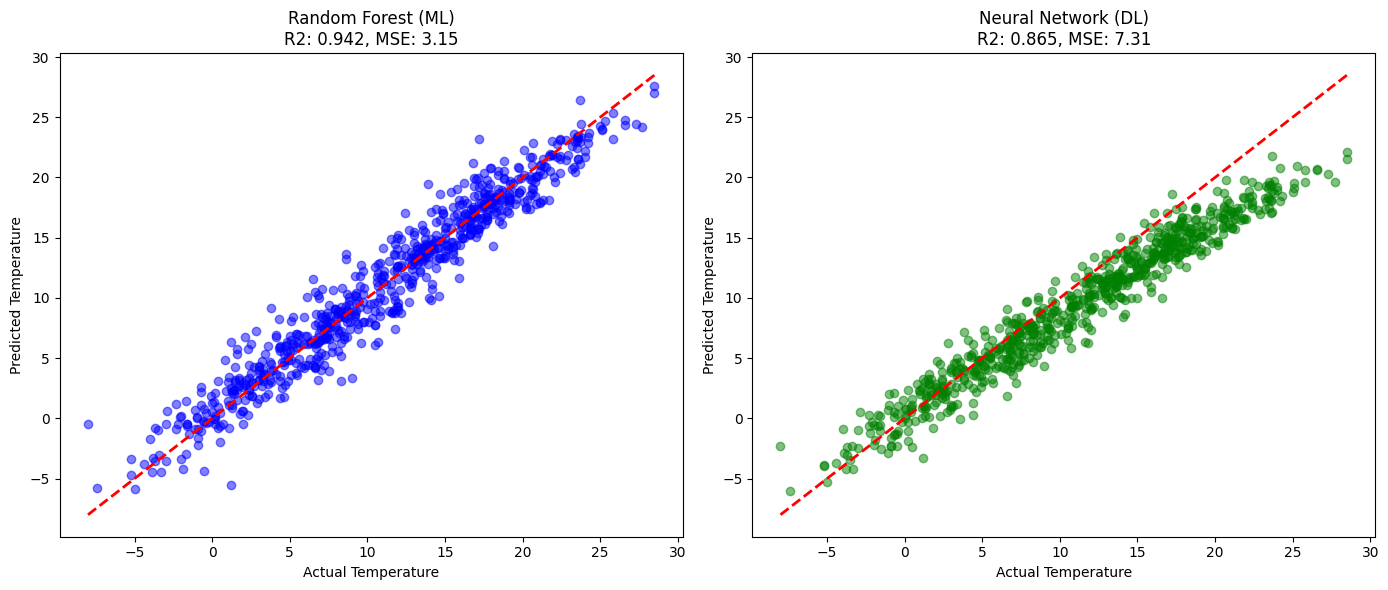

In [10]:
import matplotlib.pyplot as plt

# Plotting Predictions vs Actual for both models
plt.figure(figsize=(14, 6))

# Subplot for Random Forest
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.title(f'Random Forest (ML)\nR2: {r2_rf:.3f}, MSE: {mse_rf:.2f}')

# Subplot for Neural Network
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_dl, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.title(f'Neural Network (DL)\nR2: {r2_dl:.3f}, MSE: {mse_dl:.2f}')

plt.tight_layout()
plt.savefig('prediction_comparison.png')

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. Load and Prepare Data
df = pd.read_csv("C:/ds and AI/weather_prediction_dataset.csv")

# Target: Predict next day's mean temperature for BASEL
df['target'] = df['BASEL_temp_mean'].shift(-1)
df = df.dropna() # Remove last row which has no target

# Features (X) and Target (y)
X = df.drop(columns=['DATE', 'target'])
y = df['target']

# 2. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Machine Learning Model (Random Forest)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 4. Deep Learning Model (Neural Network)
dl_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1) # Regression output
])

dl_model.compile(optimizer='adam', loss='mse')
dl_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, verbose=0)
y_pred_dl = dl_model.predict(X_test_scaled).flatten()

# 5. Evaluate
print(f"ML R2: {r2_score(y_test, y_pred_rf):.4f}")
print(f"DL R2: {r2_score(y_test, y_pred_dl):.4f}")

C:\Users\VISWA\AppData\Local\Temp\ipykernel_47928\525411593.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['target'] = df['BASEL_temp_mean'].shift(-1)
c:\Users\VISWA\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
ML R2: 0.9417
DL R2: 0.8972


# DATA PREPROCESSING AND FEATURE ENGINEERING

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Load and basic setup
df = pd.read_csv('C:/ds and AI/weather_prediction_dataset.csv')
df['DATE'] = pd.to_datetime(df['DATE'], format='%Y%m%d')

# Feature Engineering: Lag features and Cyclical seasonality
for lag in [1, 2, 3]:
    df[f'BASEL_temp_lag_{lag}'] = df['BASEL_temp_mean'].shift(lag)

df['month_sin'] = np.sin(2 * np.pi * df['MONTH'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['MONTH'] / 12)

# Target: Next day's temperature
df['target'] = df['BASEL_temp_mean'].shift(-1)
df = df.dropna().sort_values('DATE')

# Selection and Split
features = [col for col in df.columns if 'BASEL' in col and col != 'target'] + ['month_sin', 'month_cos']
X, y = df[features], df['target']

split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Scaling
scaler_x, scaler_y = MinMaxScaler(), MinMaxScaler()
X_train_s = scaler_x.fit_transform(X_train)
X_test_s = scaler_x.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

C:\Users\VISWA\AppData\Local\Temp\ipykernel_47928\1197040323.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'BASEL_temp_lag_{lag}'] = df['BASEL_temp_mean'].shift(lag)
C:\Users\VISWA\AppData\Local\Temp\ipykernel_47928\1197040323.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['month_sin'] = np.sin(2 * np.pi * df['MONTH'] / 12)
C:\Users\VISWA\AppData\Local\Temp\ipykernel_47928\1197040323.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, wh

 # Machine Learning Prediction (Gradient Boosting)

In [14]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize and Train ML Model
gbm = GradientBoostingRegressor(n_estimators=200, max_depth=5, random_state=42)
gbm.fit(X_train, y_train)

# Predict and Evaluate
y_pred_gbm = gbm.predict(X_test)
print(f"ML (GBM) R2 Score: {r2_score(y_test, y_pred_gbm):.4f}")
print(f"ML (GBM) MAE: {mean_absolute_error(y_test, y_pred_gbm):.2f}°C")

ML (GBM) R2 Score: 0.9256
ML (GBM) MAE: 1.56°C


# Deep Learning Prediction (LSTM)

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Reshape for LSTM: [samples, time_steps, features]
X_train_lstm = X_train_s.reshape((X_train_s.shape[0], 1, X_train_s.shape[1]))
X_test_lstm = X_test_s.reshape((X_test_s.shape[0], 1, X_test_s.shape[1]))

# Build and Train DL Model
lstm = Sequential([
    LSTM(64, input_shape=(1, X_train_s.shape[1]), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])

lstm.compile(optimizer='adam', loss='mse')
lstm.fit(X_train_lstm, y_train_s, epochs=50, batch_size=32, verbose=0)

# Predict and Invert Scaling
y_pred_lstm_s = lstm.predict(X_test_lstm)
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_s).flatten()
print(f"DL (LSTM) R2 Score: {r2_score(y_test, y_pred_lstm):.4f}")

c:\Users\VISWA\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
DL (LSTM) R2 Score: 0.9299


# Visualization & Comparison

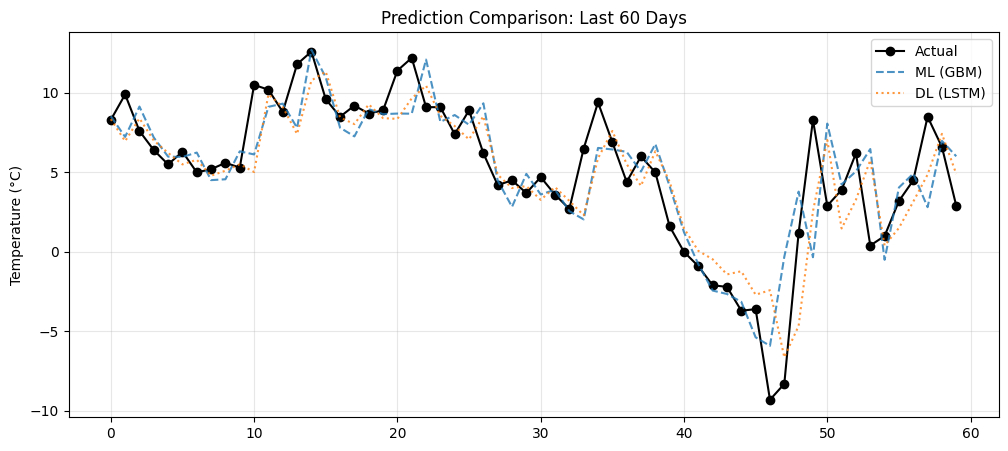

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot the last 60 days for clarity
plt.plot(y_test.values[-60:], label='Actual', color='black', marker='o')
plt.plot(y_pred_gbm[-60:], label='ML (GBM)', linestyle='--', alpha=0.8)
plt.plot(y_pred_lstm[-60:], label='DL (LSTM)', linestyle=':', alpha=0.8)

plt.title('Prediction Comparison: Last 60 Days')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Setup and Feature Correlation

C:\Users\VISWA\AppData\Local\Temp\ipykernel_47928\3044148160.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'BASEL_temp_lag_{lag}'] = df['BASEL_temp_mean'].shift(lag)


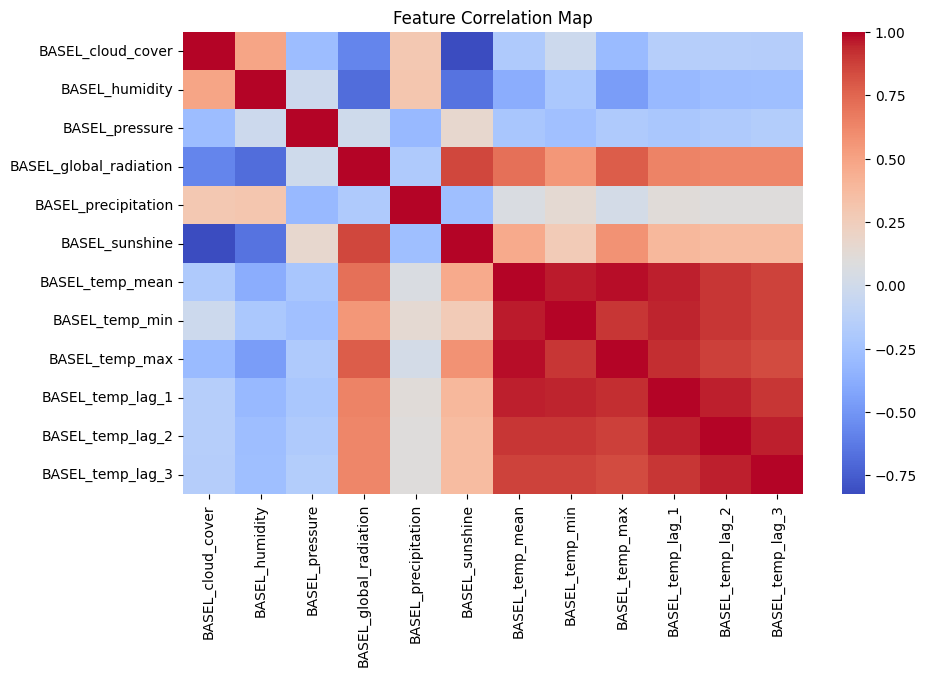

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Load & Feature Engineering
df = pd.read_csv('C:/ds and AI/weather_prediction_dataset.csv')
for lag in [1, 2, 3]:
    df[f'BASEL_temp_lag_{lag}'] = df['BASEL_temp_mean'].shift(lag)

# Plot Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[[c for c in df.columns if 'BASEL' in c]].corr(), cmap='coolwarm')
plt.title('Feature Correlation Map')
plt.show()

# Machine Learning (Gradient Boosting)

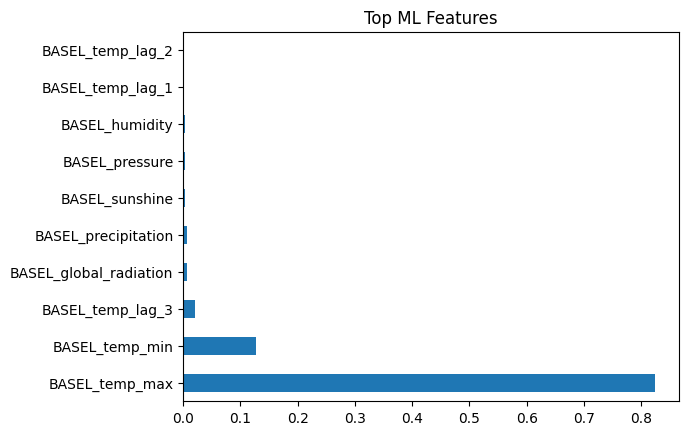

In [19]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

X = df[[c for c in df.columns if 'BASEL' in c]].dropna()
y = X.pop('BASEL_temp_mean').shift(-1).dropna()
X = X.iloc[:-1] # Match lengths

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train ML
gbm = GradientBoostingRegressor(n_estimators=100)
gbm.fit(X_train, y_train)

# Plot Feature Importance
pd.Series(gbm.feature_importances_, index=X.columns).nlargest(10).plot(kind='barh')
plt.title('Top ML Features')
plt.show()

 # Deep Learning (LSTM)

c:\Users\VISWA\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


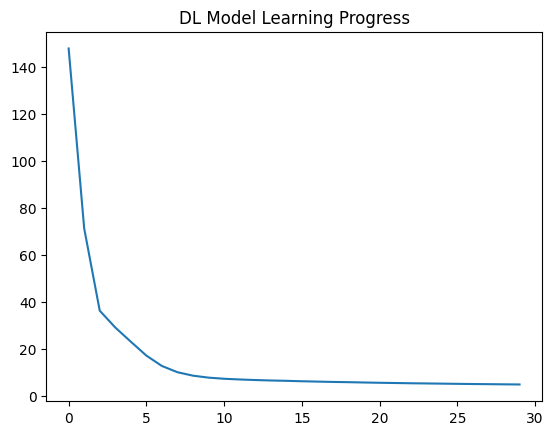

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Reshape for temporal memory
X_train_s = MinMaxScaler().fit_transform(X_train).reshape(-1, 1, X_train.shape[1])

# Build LSTM
model = Sequential([
    LSTM(50, input_shape=(1, X_train.shape[1])),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train_s, y_train, epochs=30, verbose=0)

# Plot Loss
plt.plot(history.history['loss'])
plt.title('DL Model Learning Progress')
plt.show()

# Performance Comparison

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


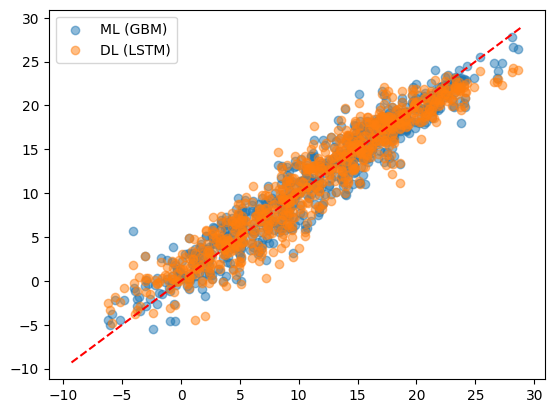

In [21]:
y_pred_ml = gbm.predict(X_test)
y_pred_dl = model.predict(MinMaxScaler().fit_transform(X_test).reshape(-1, 1, X_test.shape[1]))

# Compare Predictions
plt.scatter(y_test, y_pred_ml, label='ML (GBM)', alpha=0.5)
plt.scatter(y_test, y_pred_dl, label='DL (LSTM)', alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Perfect prediction line
plt.legend()
plt.show()